In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import joblib

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
columns_to_drop = ['target', 'FT%', 'league_ft_pct', 'Player', 'Rk', 'Awards', 'Team', 'Pos', 'Season']
x = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

x = x.select_dtypes(include=[np.number])
y = df["target"]
print("Columns being used for training:", x.columns.tolist())

Columns being used for training: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
log_model = LogisticRegression(max_iter=1000, solver='liblinear')
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
# 6. Evaluate
y_pred = log_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 90.72%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      2270
           1       0.92      0.88      0.90      1986

    accuracy                           0.91      4256
   macro avg       0.91      0.91      0.91      4256
weighted avg       0.91      0.91      0.91      4256



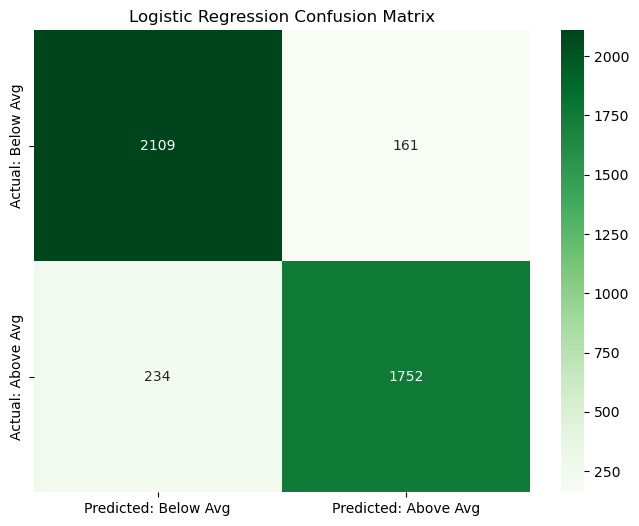

In [8]:
# 7. Visualizing the results
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted: Below Avg', 'Predicted: Above Avg'], 
            yticklabels=['Actual: Below Avg', 'Actual: Above Avg'])
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [9]:
joblib.dump(log_model, "logistic.pkl")
joblib.dump(scaler, "logistic_scaler.pkl")

['logistic_scaler.pkl']